Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Turn the data into a DataFrame

In [3]:
df = pd.read_csv("customer_churn_practice.csv")

# 1. Display the first five rows

In [4]:
df.head()

,customer_id,age,plan_type,months_active,monthly_fee,avg_weekly_usage_hours,support_tickets_90d,late_payments_12m,auto_pay,satisfaction_score,region,churned
0,CUST-0001,38,Basic,6,27.90,3.6,2,0,Yes,9.0,West,0
1,CUST-0002,32,Basic,14,25.89,7.8,3,1,Yes,4.0,South,1
2,CUST-0003,53,Basic,54,21.06,9.9,1,0,No,7.0,Midwest,0
3,CUST-0004,35,Standard,1,47.46,4.3,0,0,No,NaN,South,1
4,CUST-0005,47,Basic,33,29.96,7.7,3,0,Yes,6.0,West,0


# 2. Print the dataset shape

In [6]:
df.shape

(800, 12)

# 3. Display data types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             800 non-null    object 
 1   age                     800 non-null    int64  
 2   plan_type               800 non-null    object 
 3   months_active           800 non-null    int64  
 4   monthly_fee             800 non-null    float64
 5   avg_weekly_usage_hours  777 non-null    float64
 6   support_tickets_90d     800 non-null    int64  
 7   late_payments_12m       800 non-null    int64  
 8   auto_pay                800 non-null    object 
 9   satisfaction_score      759 non-null    float64
 10  region                  787 non-null    object 
 11  churned                 800 non-null    int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 75.1+ KB


# 4. Count missing values

In [8]:
df.isnull().sum()

customer_id                0
age                        0
plan_type                  0
months_active              0
monthly_fee                0
avg_weekly_usage_hours    23
support_tickets_90d        0
late_payments_12m          0
auto_pay                   0
satisfaction_score        41
region                    13
churned                    0
dtype: int64

# 5. Display churn counts and percentages

In [28]:
## Still reviewing this concept
# Count each value in the churned column
churn_counts = df['churned'].value_counts() # Counts the number of occurrences of each unique value in the 'churned' column.
# Convert the counts into percentages
churn_percentages = churn_counts / len(df) * 100 # Divides the counts by the total number of rows and multiplies the result by 100.
print("Counts", churn_counts)
print("Percentages", churn_percentages)

Counts churned
0    547
1    253
Name: count, dtype: int64
percentages churned
0    68.375
1    31.625
Name: count, dtype: float64


### What I learned

I originally tried filtering the customers who churned and using `.sum()`, but that did not show the counts for both classes. I learned that `.value_counts()` counts how many customers have each target value.

To calculate percentages, I divided each class count by the total number of customers and multiplied by 100. Approximately 68.4% of customers stayed, while 31.6% churned.

# 6. Check for duplicates

In [19]:
df.duplicated().sum()

np.int64(0)

# 7. Create at least two useful graphs

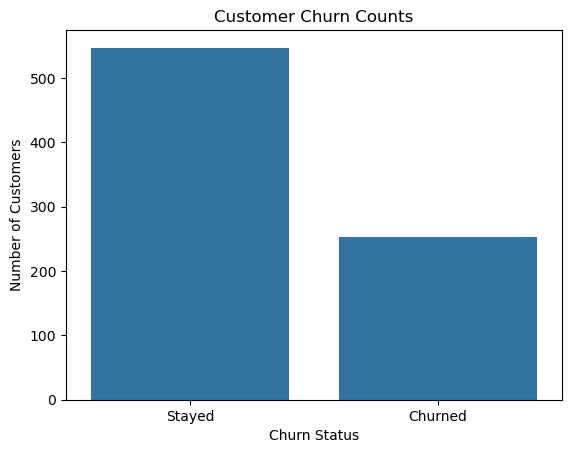

In [22]:
sns.countplot(x='churned', data=df)

plt.title('Customer Churn Counts')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.show()

We can see from the chart that more people stayed than churned.

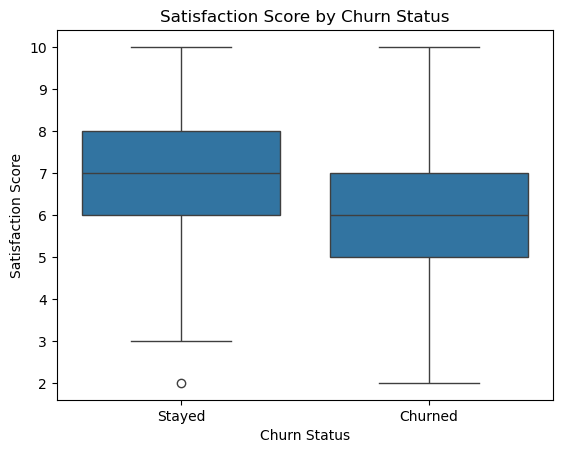

In [23]:
sns.boxplot(data=df, x="churned", y="satisfaction_score")

plt.title("Satisfaction Score by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Satisfaction Score")
plt.xticks([0, 1], ["Stayed", "Churned"])
plt.show()

We can see from the graph that satisfaction score has some relationship with churn. People with lower satisfaction scores are more likely to churn.

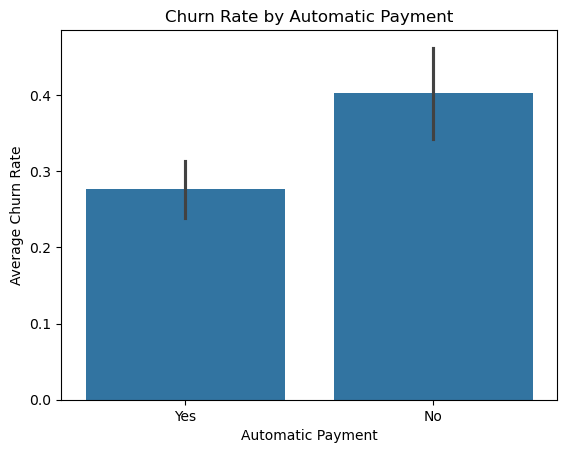

In [24]:
sns.barplot(data=df, x="auto_pay", y="churned")

plt.title("Churn Rate by Automatic Payment")
plt.xlabel("Automatic Payment")
plt.ylabel("Average Churn Rate")
plt.show()

We see that people who do not have auto pay have a higher churn rate.

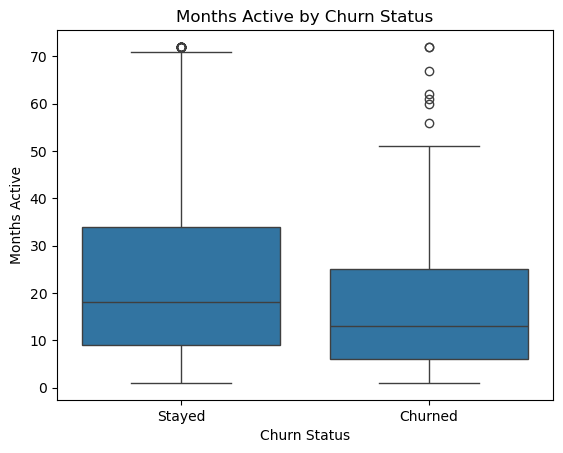

In [25]:
sns.boxplot(data=df, x="churned", y="months_active")

plt.title("Months Active by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Months Active")
plt.xticks([0, 1], ["Stayed", "Churned"])
plt.show()

We can see that customers with fewer active months tend to churn.

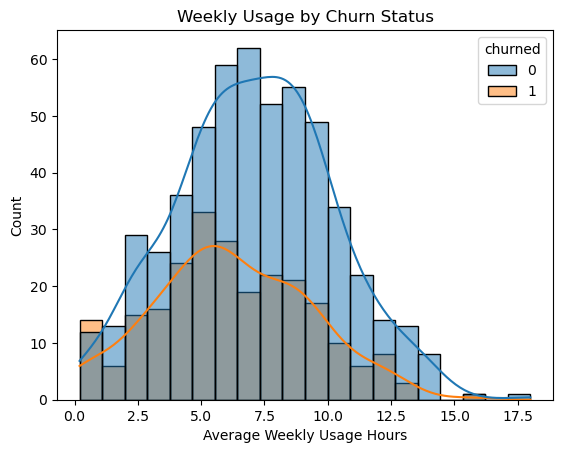

In [26]:
sns.histplot(
    data=df,
    x="avg_weekly_usage_hours",
    hue="churned",
    kde=True
)

plt.title("Weekly Usage by Churn Status")
plt.xlabel("Average Weekly Usage Hours")
plt.show()

Customers who churned had lower weekly usage.

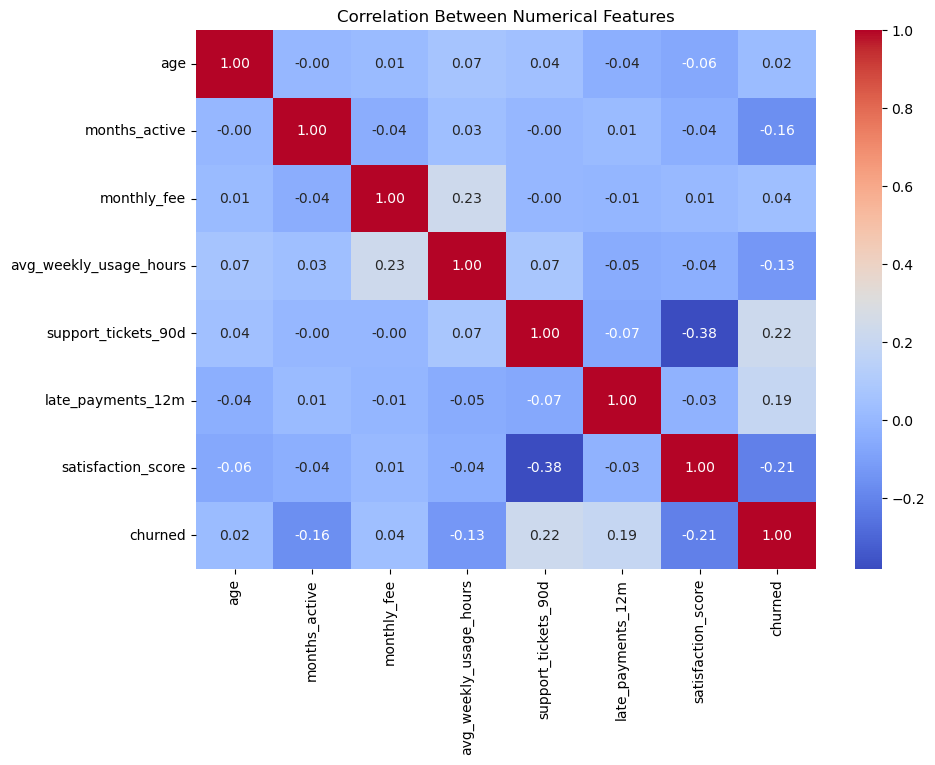

In [27]:
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

There are no extremely strong correlations with churn. This means churn is probably influenced by several features working together rather than one feature alone.

# Concept Questions
### 1. Is this classification, regression, or clustering? Why?

My answer goes here. I believe this is a classification problem because we are trying to predict whether a customer stays or churns.

### 2. Is the target reasonably balanced, or could accuracy be misleading?

My answer goes here. The target is not balanced because there are more customers who stayed.

### 3. Which column should probably be removed before training? Explain why?

My answer: `customer_id` has no real meaning for our training.

### 4. Which columns require missing-value handling?

My answer: `avg_weekly_usage_hours`, `region`, and `satisfaction_score`.

### 5. Identify the numerical and categorical features.

My answer: numerical (`age`, `months_active`, `monthly_fee`, `avg_weekly_usage_hours`, `support_tickets_90d`, `late_payments_12m`, `satisfaction_score`)
           categorical (`plan_type`, `auto_pay`, `region`)

### 6. What patterns would you investigate to understand why customers churn?

My answer: satisfaction score, late payments, and months active to see if these correlate with the churn rate.